In [ ]:
import IPython.display as ipyd
from pyspark.sql.functions import col, regexp_replace, monotonically_increasing_id
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, monotonically_increasing_id, regexp_replace


In [ ]:

spark = SparkSession.builder.getOrCreate()
df = spark.read.parquet("/home/iceberg/data/compras")
df = df.withColumn("id", monotonically_increasing_id())

df_typecasted = df.withColumn("ano", col("ano").cast("int")) \
                  .withColumn("mes", col("mes").cast("int")) \
                  .withColumn("Quantidade Item", col("Quantidade Item").cast("float")) \
                  .withColumn("Valor Item", regexp_replace(col("Valor Item"), ",", ".").cast("float"))

ids_to_remove = [25770005293, 25770005295]
df_typecasted = df_typecasted.filter(~col("id").isin(ids_to_remove))  # fix: col("id") not df["id"]

cardinality = sorted([
    (column, df_typecasted.select(F.approx_count_distinct(column)).collect()[0][0])
    for column in df_typecasted.columns if column != "id"
], key=lambda x: x[1])

ordered_cols = [c for c, _ in cardinality]

df_final = df_typecasted.select(ordered_cols) \
                        .orderBy(*[c for c, _ in cardinality])

In [21]:
spark.sql("CREATE NAMESPACE IF NOT EXISTS demo.compras")

df_final.writeTo("demo.compras.compras") \
        .tableProperty("format-version", "2") \
        .partitionedBy("ano", "mes") \
        .createOrReplace()

In [67]:
df_typecasted.printSchema()

root
 |-- Código Órgão: string (nullable = true)
 |-- Nome Órgão: string (nullable = true)
 |-- Código UG: string (nullable = true)
 |-- Nome UG: string (nullable = true)
 |-- Número Contrato: string (nullable = true)
 |-- Código Item Compra: string (nullable = true)
 |-- Descrição Item Compra: string (nullable = true)
 |-- Descrição Complementar Item Compra: string (nullable = true)
 |-- Quantidade Item: float (nullable = true)
 |-- Valor Item: float (nullable = true)
 |-- ano: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- id: long (nullable = false)



---

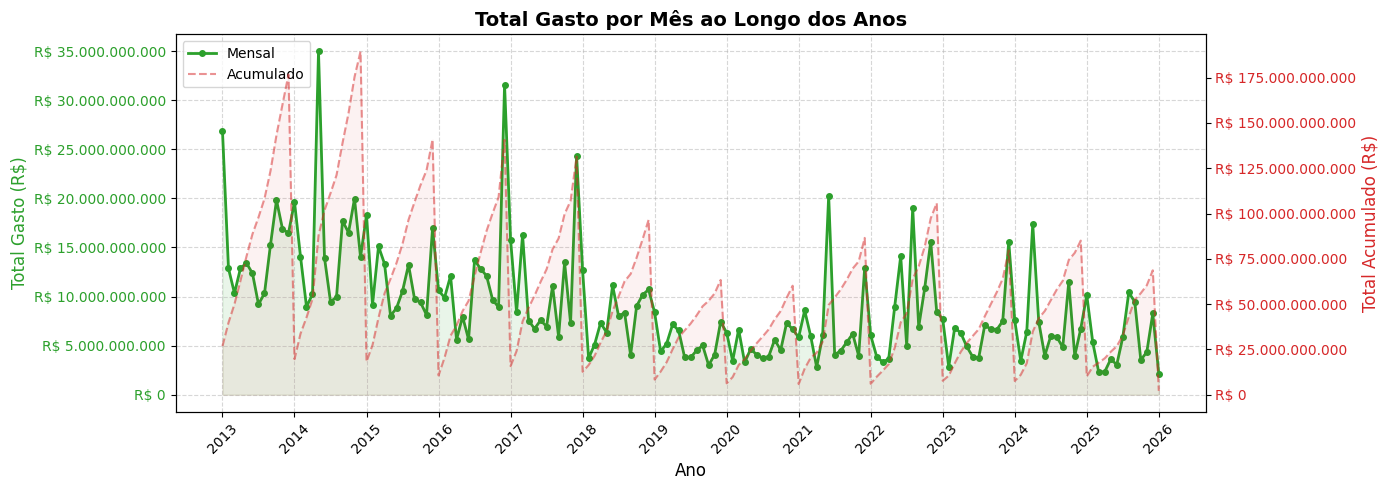

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, col

pdf = (
    df_typecasted
      .filter(
          (col("Valor Item") > 0) &
          (col("Quantidade Item") > 0) &
          (~col("id").isin([25770005293, 25770005295]))
      )
      .groupBy("ano", "mes")
      .agg(spark_sum("Valor Item").alias("total_valor"))
      .orderBy("ano", "mes")
      .toPandas()
)

pdf["month_index"] = (pdf["ano"] - pdf["ano"].min()) * 12 + (pdf["mes"] - 1)

pdf["cumsum_valor"] = pdf.groupby("ano")["total_valor"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))

ax2 = ax.twinx()
ax2.fill_between(pdf["month_index"], pdf["cumsum_valor"], alpha=0.06, color="#d62728")
ax2.plot(pdf["month_index"], pdf["cumsum_valor"], linewidth=1.5, color="#d62728", linestyle="--", alpha=0.5, label="Acumulado")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax2.set_ylabel("Total Acumulado (R$)", fontsize=12, color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

ax.plot(pdf["month_index"], pdf["total_valor"], marker="o", linewidth=2, color="#2ca02c", markersize=4, label="Mensal", zorder=3)
ax.fill_between(pdf["month_index"], pdf["total_valor"], alpha=0.1, color="#2ca02c")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax.set_ylabel("Total Gasto (R$)", fontsize=12, color="#2ca02c")
ax.tick_params(axis="y", labelcolor="#2ca02c")

years = pdf.drop_duplicates("ano").sort_values("ano")
tick_positions = ((years["ano"] - pdf["ano"].min()) * 12).tolist()
tick_labels = years["ano"].astype(str).tolist()
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)

ax.set_title("Total Gasto por Mês ao Longo dos Anos", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()